In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split
from sklearn.metrics import  r2_score
from sklearn.model_selection import cross_val_score, validation_curve
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV

In [36]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")

In [37]:
y2 = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X2 = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

In [38]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [39]:
rf2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

In [40]:
rf2.fit(X2_train, y2_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y3_pred = rf2.predict(X2_test)

In [42]:
rmse3 = root_mean_squared_error(y2_test, y3_pred)
mae3 = mean_absolute_error(y2_test, y3_pred)
r2_3 = r2_score(y2_test, y3_pred)
print(f"RMSE: {rmse3}")
print(f"MAE:  {mae3}")
print(f"R²:   {r2_3}")

RMSE: 0.6542094298403447
MAE:  0.536703768115942
R²:   0.5416458860318629


In [43]:
RCV2 = RandomizedSearchCV(estimator = RandomForestRegressor(), param_distributions={"n_estimators": [10, 33, 100], "max_depth": [2, 4, None], "min_samples_split": [2,3,4]}, scoring = "neg_root_mean_squared_error", random_state=42)
RCV_model2 = RCV2.fit(X2_train, y2_train)

In [44]:
y4_pred = RCV_model2.predict(X2_test)

In [45]:
rmse4 = root_mean_squared_error(y2_test, y4_pred)
mae4 = mean_absolute_error(y2_test, y4_pred)
r2_4 = r2_score(y2_test, y4_pred)
print(f"RMSE: {rmse4}")
print(f"MAE:  {mae4}")
print(f"R²:   {r2_4}")

RMSE: 0.6403100618495945
MAE:  0.5261182699498202
R²:   0.5609154186654528


In [46]:
GCV2 = GridSearchCV(estimator = RandomForestRegressor(), param_grid={"n_estimators": [10, 33, 100], "max_depth": [2, 4, None], "min_samples_split": [2,3,4]}, scoring = "neg_root_mean_squared_error")
GCV_model2 = GCV2.fit(X2_train, y2_train)

In [47]:
y5_pred = GCV_model2.predict(X2_test)

In [48]:
rmse5 = root_mean_squared_error(y2_test, y5_pred)
mae5 = mean_absolute_error(y2_test, y5_pred)
r2_5 = r2_score(y2_test, y5_pred)
print(f"RMSE: {rmse5}")
print(f"MAE:  {mae5}")
print(f"R²:   {r2_5}")

RMSE: 0.640767591576877
MAE:  0.5274627067628853
R²:   0.5602877039546648


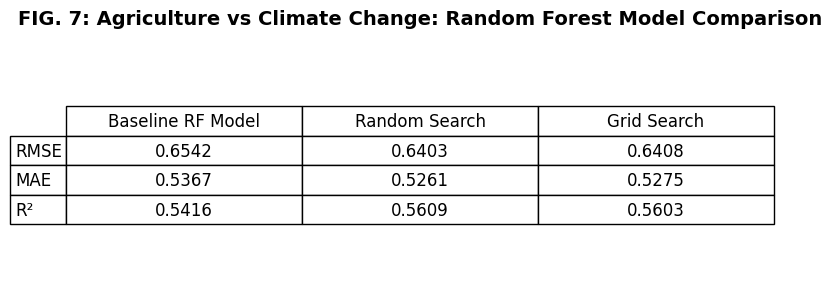

In [49]:
import matplotlib.pyplot as plt

data = [
    [round(rmse3, 4), round(rmse4, 4), round(rmse5, 4)],
    [round(mae3, 4), round(mae4, 4), round(mae5, 4)],
    [round(r2_3, 4), round(r2_4, 4), round(r2_5, 4)]
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=data,
    rowLabels=["RMSE", "MAE", "R²"],
    colLabels=["Baseline RF Model", "Random Search", "Grid Search"],
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

plt.title("FIG. 7: Agriculture vs Climate Change: Random Forest Model Comparison", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [50]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


In [51]:
y1 = clean_numeric_dfCO2["temperature_change_from_co2"]
X1 = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

In [52]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [53]:
rf1 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf1.fit(X1_train, y1_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = rf1.predict(X1_test)

In [55]:
rmse = root_mean_squared_error(y1_test, y_pred)
mae = mean_absolute_error(y1_test, y_pred)
r2 = r2_score(y1_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")
print(f"R²:   {r2}")

RMSE: 0.03366728530389766
MAE:  0.0038743085106383024
R²:   0.7756144606904498


In [56]:
RCV1 = RandomizedSearchCV(estimator = RandomForestRegressor(), param_distributions={"n_estimators": [10, 33, 100], "max_depth": [2, 4, None], "min_samples_split": [2,3,4]}, scoring = "neg_root_mean_squared_error", random_state=42)
RCV_model1 = RCV1.fit(X1_train, y1_train)

In [57]:
y_pred1 = RCV_model1.predict(X1_test)

In [58]:
rmse1 = root_mean_squared_error(y1_test, y_pred1)
mae1 = mean_absolute_error(y1_test, y_pred1)
r2_1 = r2_score(y1_test, y_pred1)

print(f"RMSE: {rmse1}")
print(f"MAE:  {mae1}")
print(f"R²:   {r2_1}")

RMSE: 0.036421960596349466
MAE:  0.004581838061465722
R²:   0.7373935995704421


In [59]:
GCV1 = GridSearchCV(estimator = RandomForestRegressor(), param_grid={"n_estimators": [10, 33, 100], "max_depth": [2, 4, None], "min_samples_split": [2,3,4]}, scoring = "neg_root_mean_squared_error")
GCV_model1 = GCV1.fit(X1_train, y1_train)

In [60]:
y2_pred = GCV_model1.predict(X1_test)

In [61]:
rmse2 = root_mean_squared_error(y1_test, y2_pred)
mae2 = mean_absolute_error(y1_test, y2_pred)
r2_2 = r2_score(y1_test, y2_pred)

print(f"RMSE: {rmse2}")
print(f"MAE:  {mae2}")
print(f"R²:   {r2_2}")

RMSE: 0.03335668406760204
MAE:  0.0037023758865248274
R²:   0.7797355496646167


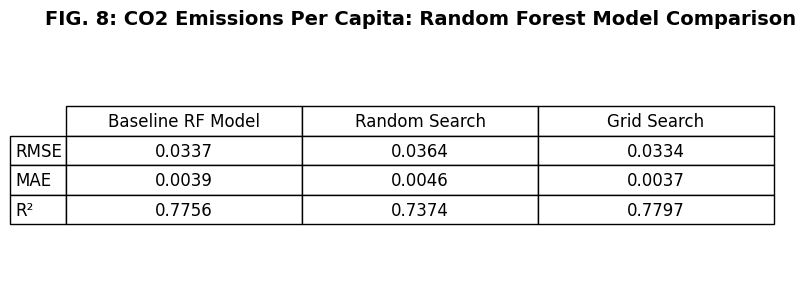

In [62]:
import matplotlib.pyplot as plt

data = [
    [round(rmse, 4), round(rmse1, 4), round(rmse2, 4)],
    [round(mae, 4), round(mae1, 4), round(mae2, 4)],
    [round(r2, 4), round(r2_1, 4), round(r2_2, 4)]
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=data,
    rowLabels=["RMSE", "MAE", "R²"],
    colLabels=["Baseline RF Model", "Random Search", "Grid Search"],
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

plt.title("FIG. 8: CO2 Emissions Per Capita: Random Forest Model Comparison", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()
